In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, Input
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

# Sütun isimleri
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
]


train_df = pd.read_csv('KDDTrain+.txt', names=columns)
test_df  = pd.read_csv('KDDTest+.txt',  names=columns)

print("Train shape:", train_df.shape)
print("Test shape:",  test_df.shape)
train_df.head()

Train shape: (125973, 43)
Test shape: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [2]:
train_df = train_df.drop('difficulty', axis=1)
test_df  = test_df.drop('difficulty', axis=1)

cat_cols = ['protocol_type', 'service', 'flag']
le = LabelEncoder()

for col in cat_cols:
    combined = pd.concat([train_df[col], test_df[col]])
    le.fit(combined)
    train_df[col] = le.transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])

train_df['label'] = train_df['label'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['label']  = test_df['label'].apply(lambda x: 0 if x == 'normal' else 1)

X_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values
X_test  = test_df.drop('label', axis=1).values
y_test  = test_df['label'].values

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:",  X_test.shape)
print("Saldırı oranı (train):", y_train.mean().round(3))
print("Saldırı oranı (test):",  y_test.mean().round(3))

X_train shape: (125973, 41)
X_test shape: (22544, 41)
Saldırı oranı (train): 0.465
Saldırı oranı (test): 0.569


In [4]:
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(41, 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()

cnn_history = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

print("\n CNN eğitimi tamamlandı!")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 39, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 17, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,481 (642.50 KB)

 Trainable params: 164,481 (642.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.9503 - loss: 0.1434 - val_accuracy: 0.9902 - val_loss: 0.0319
Epoch 2/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.9863 - loss: 0.0362 - val_accuracy: 0.9890 - val_loss: 0.0282
Epoch 3/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.9895 - loss: 0.0286 - val_accuracy: 0.9920 - val_loss: 0.0221
Epoch 4/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.9903 - loss: 0.0258 - val_accuracy: 0.9928 - val_loss: 0.0183
Epoch 5/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.9913 - loss: 0.0232 - val_accuracy: 0.9933 - val_loss: 0.0185
Epoch 6/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.9913 - loss: 0.0240 - val_accuracy: 0.9923 - val_loss: 0.0194
Epoch 7/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.9922 - loss: 0.0217 - val_accuracy: 0.9952 - val_loss: 0.0157
Epoch 8/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.9932 - loss: 0.0188 - 

In [5]:
# AUTOENCODER
encoding_dim = 16

input_layer = Input(shape=(41,))

# Encoder
encoded = Dense(32, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(32, activation='relu')(encoded)
decoded = Dense(41, activation='sigmoid')(decoded)

# Modeller
autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

# Eğitim
ae_history = autoencoder.fit(
    X_train, X_train,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

print("\n Autoencoder eğitimi tamamlandı!")

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 41)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 41)             │         1,353 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,769 (14.72 KB)

 Trainable params: 3,769 (14.72 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.9083 - val_loss: 0.6927
Epoch 2/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7423 - val_loss: 0.6796
Epoch 3/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.7050 - val_loss: 0.6767
Epoch 4/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6727 - val_loss: 0.6755
Epoch 5/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8292 - val_loss: 0.6748
Epoch 6/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6762 - val_loss: 0.6745
Epoch 7/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6698 - val_loss: 0.6743
Epoch 8/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6382 - val_loss: 0.6742
Epoch 9/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6636 - val_loss: 0.6740
Epoch 10/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6436 - val_loss: 0.6737
Epoch 11/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8405 - val_loss: 0.6735
Epoch 12/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

In [6]:
# Encoder ile özellik çıkar (41 → 16 boyut)
X_train_encoded = encoder.predict(X_train)
X_test_encoded  = encoder.predict(X_test)

# CNN için reshape (16 → (16, 1))
X_train_ae_cnn = X_train_encoded.reshape(X_train_encoded.shape[0], X_train_encoded.shape[1], 1)
X_test_ae_cnn  = X_test_encoded.reshape(X_test_encoded.shape[0], X_test_encoded.shape[1], 1)

print("AE çıktı shape:", X_train_ae_cnn.shape)

# AE-CNN Modeli
ae_cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(16, 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

ae_cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ae_cnn_model.summary()

# Eğitim
ae_cnn_history = ae_cnn_model.fit(
    X_train_ae_cnn, y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

print("\n AE-CNN eğitimi tamamlandı!")

3937/3937 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
AE çıktı shape: (125973, 16, 1)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 14, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        57,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,049 (258.00 KB)

 Trainable params: 66,049 (258.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9263 - loss: 0.1812 - val_accuracy: 0.9823 - val_loss: 0.0447
Epoch 2/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9817 - loss: 0.0494 - val_accuracy: 0.9874 - val_loss: 0.0355
Epoch 3/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9853 - loss: 0.0421 - val_accuracy: 0.9890 - val_loss: 0.0302
Epoch 4/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9856 - loss: 0.0392 - val_accuracy: 0.9894 - val_loss: 0.0310
Epoch 5/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9868 - loss: 0.0355 - val_accuracy: 0.9896 - val_loss: 0.0279
Epoch 6/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9873 - loss: 0.0341 - val_accuracy: 0.9901 - val_loss: 0.0258
Epoch 7/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9878 - loss: 0.0329 - val_accuracy: 0.9907 - val_loss: 0.0247
Epoch 8/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9888 - loss: 0.0299 - val_accu

705/705 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
         CNN MODEL SONUÇLARI
              precision    recall  f1-score   support

      Normal       0.64      0.96      0.77      9711
     Saldırı       0.95      0.59      0.73     12833

    accuracy                           0.75     22544
   macro avg       0.80      0.78      0.75     22544
weighted avg       0.82      0.75      0.75     22544

       AE-CNN MODEL SONUÇLARI
              precision    recall  f1-score   support

      Normal       0.66      0.98      0.79      9711
     Saldırı       0.98      0.62      0.76     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.77     22544



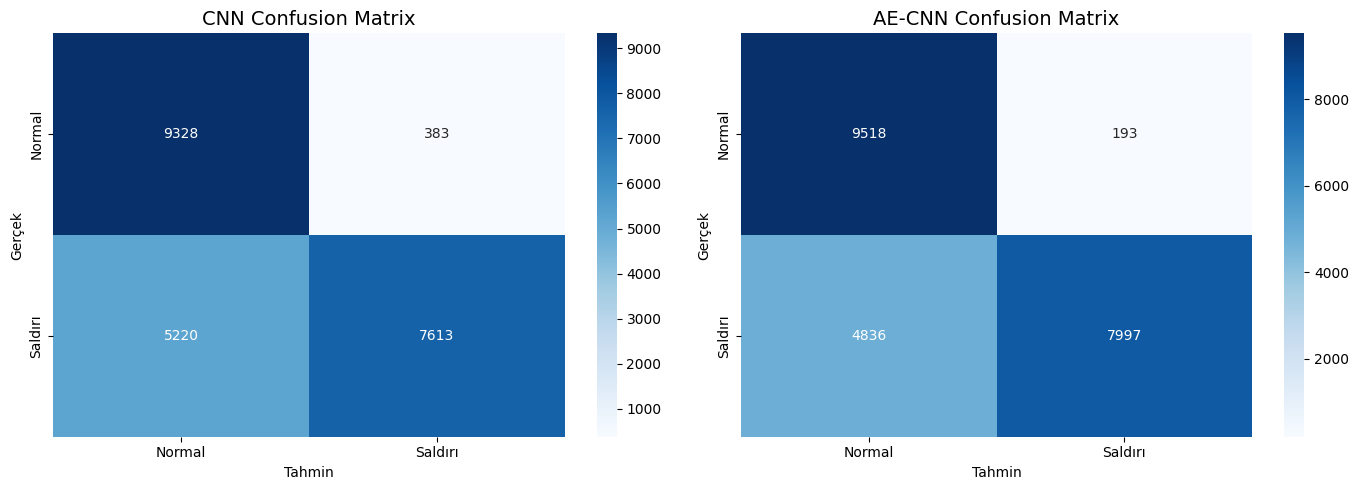

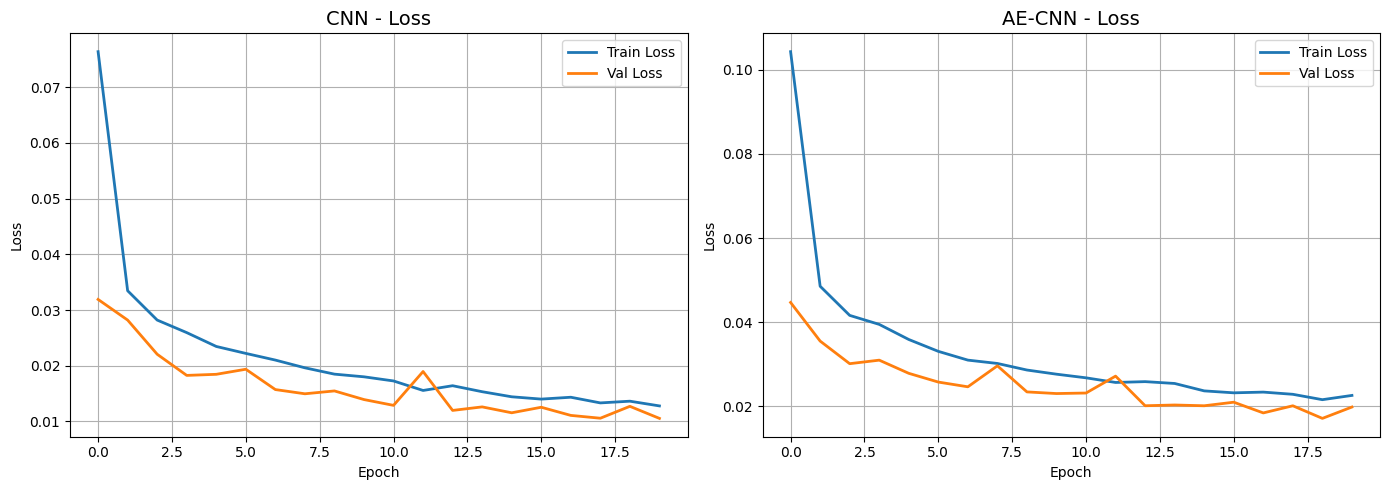

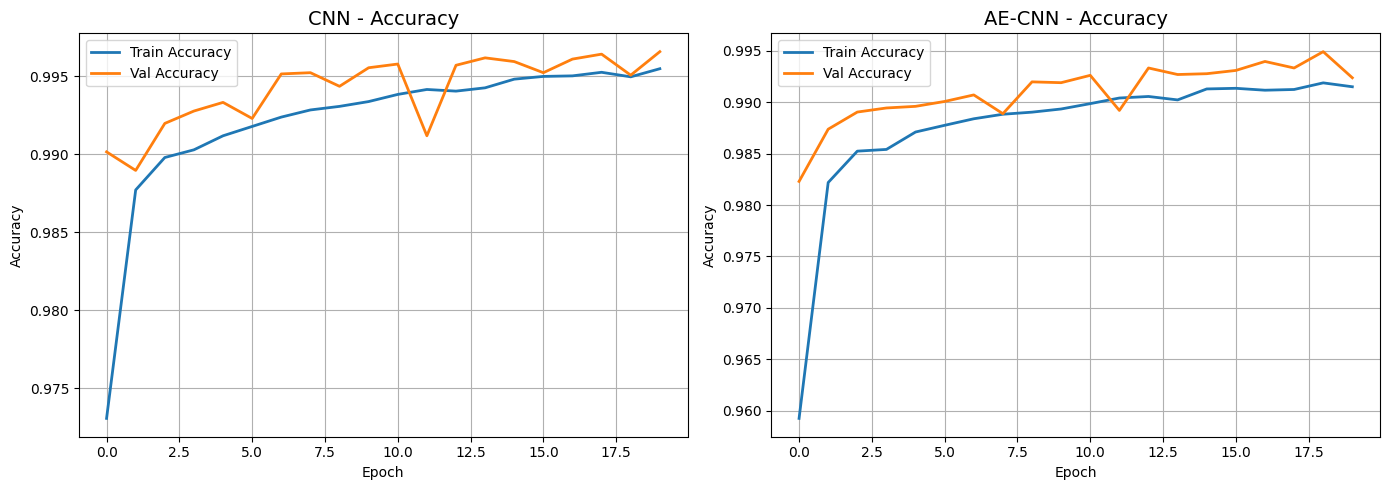


 KARŞILAŞTIRMA TABLOSU
        Accuracy  Precision  Recall  F1-Score
Model                                        
CNN       0.7515     0.9521  0.5932    0.7310
AE-CNN    0.7769     0.9764  0.6232    0.7608


In [7]:
#TAHMİNLER
y_pred_cnn     = (cnn_model.predict(X_test_cnn) > 0.5).astype(int)
y_pred_ae_cnn  = (ae_cnn_model.predict(X_test_ae_cnn) > 0.5).astype(int)

#METRİKLER
print("=" * 50)
print("         CNN MODEL SONUÇLARI")
print("=" * 50)
print(classification_report(y_test, y_pred_cnn, target_names=['Normal', 'Saldırı']))

print("=" * 50)
print("       AE-CNN MODEL SONUÇLARI")
print("=" * 50)
print(classification_report(y_test, y_pred_ae_cnn, target_names=['Normal', 'Saldırı']))

#CONFUSION MATRIX
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(axes,
                              [y_pred_cnn, y_pred_ae_cnn],
                              ['CNN', 'AE-CNN']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Saldırı'],
                yticklabels=['Normal', 'Saldırı'])
    ax.set_title(f'{title} Confusion Matrix', fontsize=14)
    ax.set_ylabel('Gerçek')
    ax.set_xlabel('Tahmin')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

#LOSS GRAFİKLERİ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, history, title in zip(axes,
                               [cnn_history, ae_cnn_history],
                               ['CNN', 'AE-CNN']):
    ax.plot(history.history['loss'], label='Train Loss', linewidth=2)
    ax.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    ax.set_title(f'{title} - Loss', fontsize=14)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('loss_graphs.png', dpi=150)
plt.show()

#ACCURACY GRAFİKLERİ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, history, title in zip(axes,
                               [cnn_history, ae_cnn_history],
                               ['CNN', 'AE-CNN']):
    ax.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    ax.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    ax.set_title(f'{title} - Accuracy', fontsize=14)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('accuracy_graphs.png', dpi=150)
plt.show()

#KARŞILAŞTIRMA TABLOSU
from sklearn.metrics import precision_score, recall_score, f1_score

results = {
    'Model':     ['CNN', 'AE-CNN'],
    'Accuracy':  [accuracy_score(y_test, y_pred_cnn),
                  accuracy_score(y_test, y_pred_ae_cnn)],
    'Precision': [precision_score(y_test, y_pred_cnn),
                  precision_score(y_test, y_pred_ae_cnn)],
    'Recall':    [recall_score(y_test, y_pred_cnn),
                  recall_score(y_test, y_pred_ae_cnn)],
    'F1-Score':  [f1_score(y_test, y_pred_cnn),
                  f1_score(y_test, y_pred_ae_cnn)]
}

results_df = pd.DataFrame(results).set_index('Model')
print("\n KARŞILAŞTIRMA TABLOSU")
print(results_df.round(4))